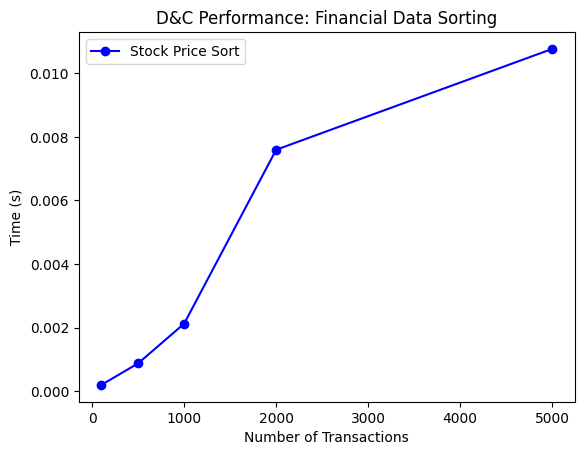

In [1]:
import time, random, matplotlib.pyplot as plt

def quicksort_stocks(prices):
    """Sorts daily stock prices using the Divide and Conquer approach."""
    if len(prices) <= 1:
        return prices
    # Picking the first element as the pivot
    pivot = prices[0]
    less = [x for x in prices[1:] if x <= pivot]
    greater = [x for x in prices[1:] if x > pivot]
    return quicksort_stocks(less) + [pivot] + quicksort_stocks(greater)

def plot_stock_sorting():
    sizes = [100, 500, 1000, 2000, 5000]
    times = []
    for s in sizes:
        # Simulating random market price data
        data = [random.uniform(10.0, 500.0) for _ in range(s)]
        start = time.time()
        quicksort_stocks(data)
        times.append(time.time() - start)

    plt.plot(sizes, times, marker='o', color='blue', label='Stock Price Sort')
    plt.title("D&C Performance: Financial Data Sorting")
    plt.xlabel("Number of Transactions"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_stock_sorting()

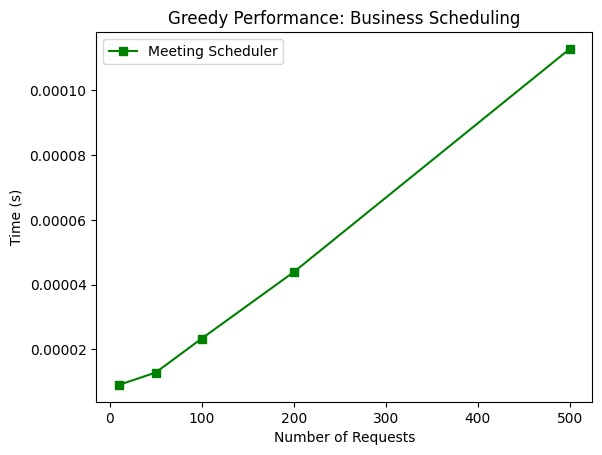

In [2]:

def schedule_meetings(meetings):
    """Greedy strategy to maximize the number of meetings in one boardroom."""
    # Sort meetings based on their end times (locally optimal choice)
    meetings.sort(key=lambda x: x[1])

    selected_meetings = [meetings[0]]
    last_end_time = meetings[0][1]

    for i in range(1, len(meetings)):
        # If the start time is after the last selected meeting ends
        if meetings[i][0] >= last_end_time:
            selected_meetings.append(meetings[i])
            last_end_time = meetings[i][1]

    return selected_meetings

def plot_meeting_greedy():
    sizes = [10, 50, 100, 200, 500]
    times = []
    for s in sizes:
        # Generating random (start, end) time pairs
        test_meetings = []
        for _ in range(s):
            start = random.randint(1, 20)
            test_meetings.append((start, start + random.randint(1, 5)))

        start_t = time.time()
        schedule_meetings(test_meetings)
        times.append(time.time() - start_t)

    plt.plot(sizes, times, marker='s', color='green', label='Meeting Scheduler')
    plt.title("Greedy Performance: Business Scheduling")
    plt.xlabel("Number of Requests"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_meeting_greedy()

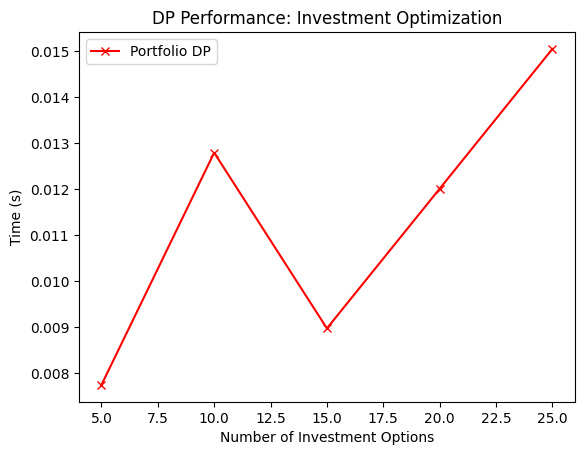

In [3]:
def portfolio_dp(budget, costs, returns, n):
    """Dynamic Programming to optimize financial returns within a budget."""
    # Creating the DP table
    table = [[0 for _ in range(budget + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for b in range(1, budget + 1):
            if costs[i-1] <= b:
                # Decide whether to include the investment or not
                table[i][b] = max(returns[i-1] + table[i-1][b-costs[i-1]], table[i-1][b])
            else:
                table[i][b] = table[i-1][b]

    return table[n][budget]

def plot_portfolio_dp():
    sizes = [5, 10, 15, 20, 25] # DP is computationally heavier
    times = []
    for s in sizes:
        c = [random.randint(100, 1000) for _ in range(s)]
        r = [random.randint(50, 500) for _ in range(s)]
        start = time.time()
        portfolio_dp(2000, c, r, s)
        times.append(time.time() - start)

    plt.plot(sizes, times, marker='x', color='red', label='Portfolio DP')
    plt.title("DP Performance: Investment Optimization")
    plt.xlabel("Number of Investment Options"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_portfolio_dp()

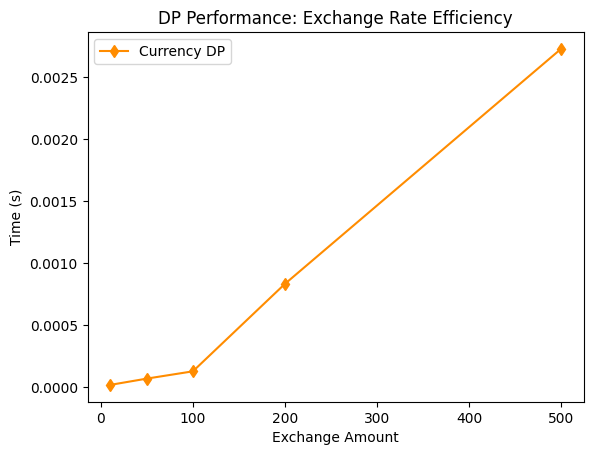

In [4]:
def min_currency_notes(notes, target):
    """DP approach to find the minimum notes needed for an exchange amount."""
    # Initialize DP table with a value larger than target
    dp = [target + 1] * (target + 1)
    dp[0] = 0

    for i in range(1, target + 1):
        for note in notes:
            if i - note >= 0:
                dp[i] = min(dp[i], 1 + dp[i - note])

    return dp[target] if dp[target] <= target else -1

# --- Visualization for Problem 5 ---
def plot_currency_exchange():
    amounts = [10, 50, 100, 200, 500]
    denominations = [1, 2, 5, 10, 20, 50, 100]
    times = []
    for a in amounts:
        start = time.time()
        min_currency_notes(denominations, a)
        times.append(time.time() - start)

    plt.plot(amounts, times, marker='d', color='darkorange', label='Currency DP')
    plt.title("DP Performance: Exchange Rate Efficiency")
    plt.xlabel("Exchange Amount"); plt.ylabel("Time (s)"); plt.legend(); plt.show()

plot_currency_exchange()